# MRI acceleration

In [6]:
import os
import h5py
from tqdm import tqdm
import json
import numpy as np
from utils import dft2, generate_mask, kernel_projection, kernel_draw,load_model, transform_batch, predict_batch, process_image_V2, segment_brain
from functools import partial
import torch
from matplotlib import pyplot as plt


In [7]:
SNR = 50
epsilon_20DB_full = 0.1*0.0227*(8**0.5) # Value corresponding to a common l2 norm of fully sampled MRI Scan in the processed Brain SC data
epsilon_20DB = epsilon_20DB_full/(8**0.5)
epsilon = epsilon_20DB * 10**((20/20)-(SNR/20))

acceleration_rate = 8
shape_k = (320,320)
k_mask = generate_mask(acceleration_rate, 22,shape_k)
P_null = partial(kernel_projection, k_mask = k_mask, max_norm = epsilon)
kerdraw = partial(kernel_draw,P_null = P_null )

## Get dataset information and save Single Coil Brain MRI data

In [8]:
data_folder = '/localhome/iaga_dv/Dokumente/MRI_data'
fp_brain = f'{data_folder}/brain/multicoil_val' # Path for raw brain multicoil data
data_info_path  = f'{data_folder}/Brain_datainfo_test.json'  # Path for dataset information file
processed_SC_folder_brain = f'{data_folder}/brain/SC_processed_test'  # Path to save the processed Brain SingleCoil data

files_brain = os.listdir(fp_brain)


### Get the information of the dataset and save it

In [9]:
fileorder = []
files_info = {}

for file in tqdm(files_brain):
    fileorder.append(file)

    hf = h5py.File(f'{fp_brain}/{file}')

    k_mes = hf['kspace'][()]
    x_mes = hf['reconstruction_rss'][()]

    ns,nc = k_mes.shape[0], 16  # The number of coils does actually not matter here, so we set it to 16 to match the format
    files_info[file] = [ns,nc]

with open(data_info_path, "w") as outfile:
    json.dump({'fileorder': fileorder, 'files_info': files_info }, outfile, indent=4)

100%|██████████| 3/3 [00:00<00:00,  3.78it/s]


### Process the MRI scans into singlecoil, fixed size and save them

In [ ]:
# Process each brain MRI file: crop, resize, and save processed data to HDF5
for file in tqdm(files_brain):
    # Construct file path
    fp = os.path.join(fp_brain, file)
    # Open HDF5 file
    hf = h5py.File(fp, 'r')
    # Load k-space and image data
    k_mes = hf['kspace'][()]
    x_mes = hf['reconstruction_rss'][()]

    # Process image: crop and resize around ROI to 320x320
    k_out, x_rec_out = process_image_V2(k_mes, (320, 320), margin_ratio=1.15)
    n_slices = k_out.shape[0]
    # Compute magnitude image from complex reconstruction
    x_mag = (np.sum(np.abs(x_rec_out)**2, axis=1))**0.5

    # Initialize lists for processed slices
    k_slices_new = []
    x_slices_new = []

    # Process each slice
    for slice in range(n_slices):
        x_rec = x_mag[slice]
        k_mes = dft2(x_rec)
        k_slices_new.append(k_mes)
        x_slices_new.append(x_rec)

    # Stack slices into arrays
    k_slices_new = np.stack(k_slices_new, axis=0)
    x_slices_new = np.stack(x_slices_new, axis=0)

    # Save processed data to new HDF5 file
    with h5py.File(f'{processed_SC_folder_brain}/{file}', 'a') as f:
        f.create_dataset(
            'x',
            data=x_slices_new,
            shape=(n_slices, 320, 320),
            maxshape=(n_slices, 320, 320),
            chunks=(1, 320, 320),
            compression='lzf'
        )
        f.create_dataset(
            'k_mes',
            data=k_slices_new,
            shape=(n_slices, 320, 320),
            maxshape=(n_slices, 320, 320),
            chunks=(1, 320, 320),
            compression='lzf'
        )

## Bounds sharpness assessment

First save  the slice 0 and the slice 1 of each MRI scans of a given subdataset, under .npy files

In [ ]:
# Extract and save specific slices from processed data for further analysis
subds_folder = '/localhome/iaga_dv/Dokumente/MRI_data/brain/SC_processed_subds_test'
count = 0

for file in files_brain:
    # Construct file path
    fp = os.path.join(processed_SC_folder_brain, file)
    # Open HDF5 file
    hf = h5py.File(fp, 'r')
    # Load image data
    x_img = hf['x'][()]

    # Extract first two slices
    slice_0 = x_img[0]
    slice_1 = x_img[1]

    # Save slices as numpy arrays
    np.save(os.path.join(subds_folder, f'scan{count}_sl0.npy'), slice_0)
    np.save(os.path.join(subds_folder, f'scan{count}_sl1.npy'), slice_1)
    count += 1



Then, run the computations and save the results into a json file

In [4]:
# Perform quantitative analysis on MRI slices and save results to JSON
json_path = '/localhome/iaga_dv/Dokumente/MRI_data/brain/quant_data_test.json'
json_path_temp = '/localhome/iaga_dv/Dokumente/MRI_data/brain/quant_data_test_temp.json'
subds_folder = '/localhome/iaga_dv/Dokumente/MRI_data/brain/SC_processed_subds_test'

# Get list of processed files
filenames = os.listdir(subds_folder)
scans_ids = list(set([x.split('_')[0] for x in filenames]))

# Initialize result lists
fileorder = []
inputs_diff_SNR = []
consistencies_fromy_SNR = []
consistencies_fromart_SNR = []
diameters = []
deltas_pred = []
errs_GT_fromy = []
errs_art_fromy = []
errs_GT_fromart = []
errs_art_fromart = []
count = 0

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model(device)

# Process each scan
for scan_id in tqdm(scans_ids):
    # Update file order
    fileorder.append(scan_id)

    # Load slices
    path_sl0 = os.path.join(subds_folder, f'{scan_id}_sl0.npy')
    path_sl1 = os.path.join(subds_folder, f'{scan_id}_sl1.npy')
    GT_img = np.load(path_sl0)
    lim1_img = np.load(path_sl1)

    # Segment brain region
    mask_brain = segment_brain(GT_img)
    xs, ys = np.where(mask_brain == 1)
    ymin, ymax = ys.min(), ys.max()
    xmin, xmax = xs.min(), xs.max()

    # Define ROI for ventricle region
    xmin_ROI = int(0.75*xmin + 0.25*xmax)
    xmax_ROI = int(0.25*xmin + 0.75*xmax)
    ymin_ROI = int(0.7*ymin + 0.3*ymax)
    ymax_ROI = int(0.3*ymin + 0.7*ymax)

    # Create ROI mask
    mask_ROI = np.zeros_like(GT_img, dtype=np.uint8)
    mask_ROI[xmin_ROI:xmax_ROI, ymin_ROI:ymax_ROI] = 1

    # Apply detail pasting algorithm
    lim1_artificial = kerdraw(GT_img, lim1_img, mask_ROI)

    # Prepare k-space data for prediction
    GT_kfull = dft2(GT_img)
    input_img = GT_kfull * k_mask
    k_lim1_artificial = k_mask * dft2(lim1_artificial)

    # Stack input data
    k_SC = np.stack([input_img, k_lim1_artificial], axis=0)

    # Transform and predict
    k_trans, means, stds = transform_batch(k_SC, k_mask)
    preds_batch = predict_batch(model, k_trans, means, stds, device)

    # Extract predictions
    pred_fromy = preds_batch[0]
    pred_fromartificial = preds_batch[1]

    # Transform predictions to k-space
    forwarded_pred_fromy = dft2(pred_fromy) * k_mask
    forwarded_pred_fromartificial = dft2(pred_fromartificial) * k_mask

    # Compute consistency metrics
    consistency_ratio_fromy = np.linalg.norm(input_img - forwarded_pred_fromy, ord=2) / np.linalg.norm(input_img, ord=2)
    consistency_SNR_fromy = -20 * np.log10(consistency_ratio_fromy)
    consistency_ratio_fromart = np.linalg.norm(input_img - forwarded_pred_fromartificial, ord=2) / np.linalg.norm(input_img, ord=2)
    consistency_SNR_fromart = -20 * np.log10(consistency_ratio_fromart)
    noise_ratio = np.linalg.norm(input_img - k_lim1_artificial, ord=2) / np.linalg.norm(input_img, ord=2)
    SNR_val = -20 * np.log10(noise_ratio)

    # Store metrics
    inputs_diff_SNR.append(SNR_val)
    consistencies_fromy_SNR.append(consistency_SNR_fromy)
    consistencies_fromart_SNR.append(consistency_SNR_fromart)

    # Compute error metrics
    err_GT_fromy = np.linalg.norm((pred_fromy - GT_img) * mask_ROI, ord=1)
    err_artificial_frompredy = np.linalg.norm((pred_fromy - lim1_artificial) * mask_ROI, ord=1)
    err_GT_fromartificial = np.linalg.norm((pred_fromartificial - GT_img) * mask_ROI, ord=1)
    err_artificial_fromartificial = np.linalg.norm((pred_fromartificial - lim1_artificial) * mask_ROI, ord=1)
    diameter = np.linalg.norm((GT_img - lim1_artificial) * mask_ROI, ord=1)
    delta_pred = np.linalg.norm((pred_fromartificial - pred_fromy) * mask_ROI, ord=1)

    # Store error metrics
    diameters.append(diameter)
    deltas_pred.append(delta_pred)
    errs_GT_fromy.append(err_GT_fromy)
    errs_art_fromy.append(err_artificial_frompredy)
    errs_GT_fromart.append(err_GT_fromartificial)
    errs_art_fromart.append(err_artificial_fromartificial)

    # Periodically save intermediate results
    if count % 5 == 0:
        res_dict = {
            'fileorder': fileorder,
            'inputs_diff_SNR': inputs_diff_SNR,
            'consistencies_fromy_SNR': consistencies_fromy_SNR,
            'consistencies_fromart_SNR': consistencies_fromart_SNR,
            'diameters': diameters,
            'deltas_pred': deltas_pred,
            'errs_GT_fromy': errs_GT_fromy,
            'errs_art_fromy': errs_art_fromy,
            'errs_GT_fromart': errs_GT_fromart,
            'errs_art_fromart': errs_art_fromart,
        }
        with open(json_path_temp, "w") as f:
            json.dump(res_dict, f, indent=4)
    count += 1

# Save final results
res_dict = {
    'fileorder': fileorder,
    'inputs_diff_SNR': inputs_diff_SNR,
    'consistencies_fromy_SNR': consistencies_fromy_SNR,
    'consistencies_fromart_SNR': consistencies_fromart_SNR,
    'diameters': diameters,
    'deltas_pred': deltas_pred,
    'errs_GT_fromy': errs_GT_fromy,
    'errs_art_fromy': errs_art_fromy,
    'errs_GT_fromart': errs_GT_fromart,
    'errs_art_fromart': errs_art_fromart,
}
with open(json_path, "w") as f:
    json.dump(res_dict, f, indent=4)



  0%|          | 0/3 [00:00<?, ?it/s]/localhome/iaga_dv/Dokumente/AccuracyBounds/examples/MRI_code/utils.py:498: ComplexWarning: Casting complex values to real discards the imaginary part
  res_noblend[mask_ROI == 1] = detail[mask_ROI == 1]
100%|██████████| 3/3 [01:22<00:00, 27.40s/it]


Finally, visualize the results

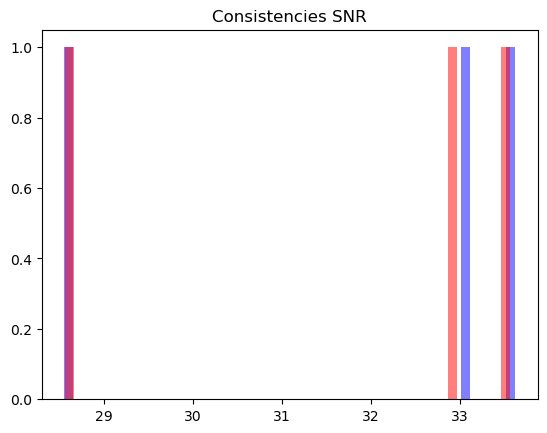

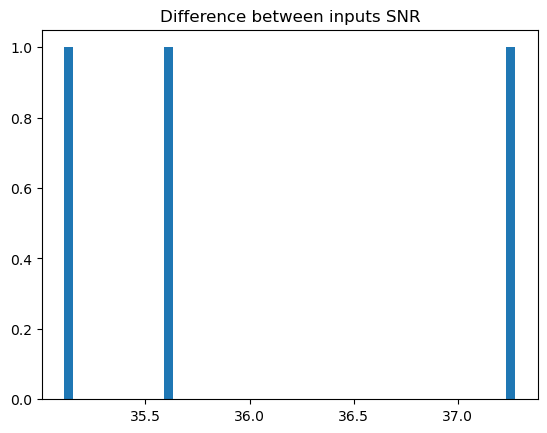

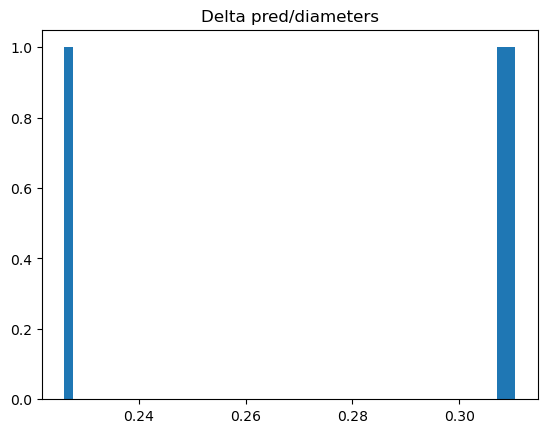

Errors original vs diameters


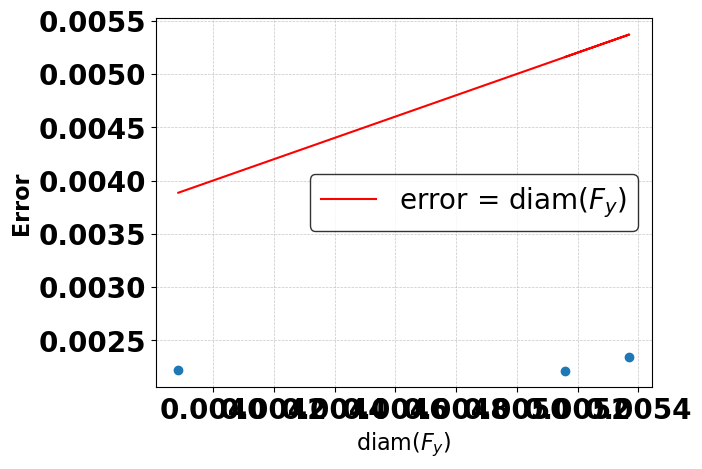

Predictions from artificial


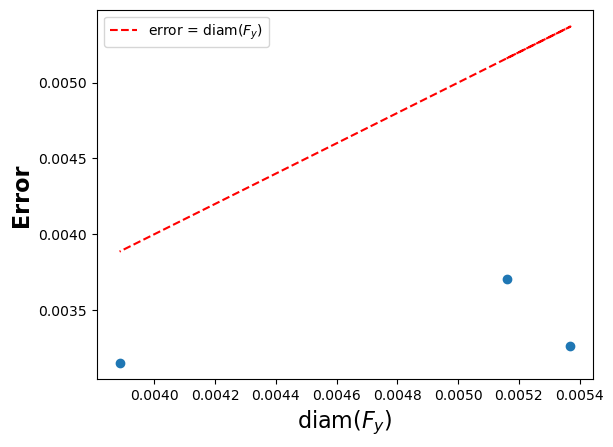

Scatter plot errors wc vs diameters
Predictions from y


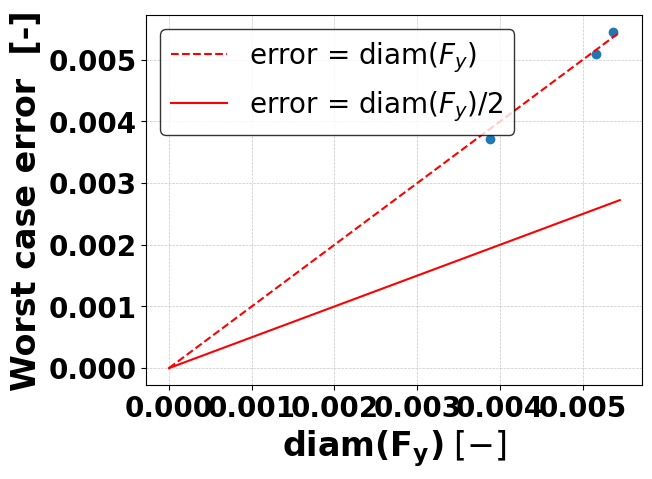

Predictions from artificial


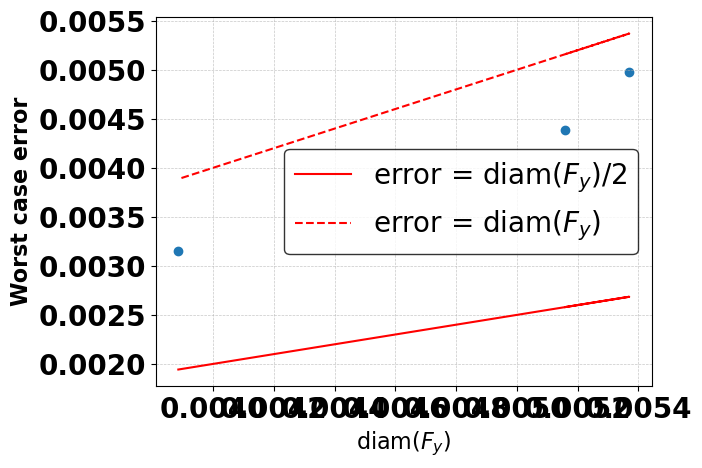

In [5]:
# Load and analyze quantitative results from JSON
json_path = '/localhome/iaga_dv/Dokumente/MRI_data/brain/quant_data_test.json'
with open(json_path, 'r') as f:
    res_dict = json.load(f)

# Load results into numpy arrays
fileorder = np.array(res_dict['fileorder'])
inputs_diff_SNR = np.array(res_dict['inputs_diff_SNR'])
consistencies_fromy_SNR = np.array(res_dict['consistencies_fromy_SNR'])
consistencies_fromart_SNR = np.array(res_dict['consistencies_fromart_SNR'])
diameters = np.array(res_dict['diameters'])
deltas_pred = np.array(res_dict['deltas_pred'])
errs_GT_fromy = np.array(res_dict['errs_GT_fromy'])
errs_art_fromy = np.array(res_dict['errs_art_fromy'])
errs_GT_fromart = np.array(res_dict['errs_GT_fromart'])
errs_art_fromart = np.array(res_dict['errs_art_fromart'])

# Filter valid results based on quality criteria
idxs_valid = (
    (consistencies_fromy_SNR > 26) &
    (consistencies_fromart_SNR > 26) &
    (inputs_diff_SNR > 30) &
    ((deltas_pred / diameters) < 0.33)
)

# Apply filter to all arrays
fileorder = fileorder[idxs_valid]
inputs_diff_SNR = inputs_diff_SNR[idxs_valid]
consistencies_fromy_SNR = consistencies_fromy_SNR[idxs_valid]
consistencies_fromart_SNR = consistencies_fromart_SNR[idxs_valid]
diameters = diameters[idxs_valid]
deltas_pred = deltas_pred[idxs_valid]
errs_GT_fromy = errs_GT_fromy[idxs_valid]
errs_art_fromy = errs_art_fromy[idxs_valid]
errs_GT_fromart = errs_GT_fromart[idxs_valid]
errs_art_fromart = errs_art_fromart[idxs_valid]

# Compute worst-case errors
errs_wc_fromy = np.maximum(errs_GT_fromy, errs_art_fromy)
errs_wc_fromart = np.maximum(errs_GT_fromart, errs_art_fromart)

# Plot consistency histograms
plt.hist(consistencies_fromy_SNR, alpha=0.5, color='b', bins=50)
plt.hist(consistencies_fromart_SNR, alpha=0.5, color='r', bins=50)
plt.title('Consistencies SNR')
plt.show()

# Plot input difference SNR histogram
plt.hist(inputs_diff_SNR, bins=50)
plt.title('Difference between inputs SNR')
plt.show()

# Plot delta pred/diameters ratio histogram
plt.hist(deltas_pred / diameters, bins=50)
plt.title('Delta pred/diameters')
plt.show()

# Scatter plot: errors vs diameters (original predictions)
print('Errors original vs diameters')
plt.scatter(diameters, errs_GT_fromy)
plt.plot(diameters, diameters, color='red', linestyle='-', label=r'error = $\mathrm{diam}(F_y)$')
plt.xlabel(r'$\mathrm{diam}(F_y)$', fontsize=16, fontweight='bold')
plt.ylabel('Error', fontsize=16, fontweight='bold')
plt.legend(fontsize=20, loc='best', frameon=True, fancybox=True, edgecolor='black')
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=20, fontweight='bold')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

# Scatter plot: errors vs diameters (artificial predictions)
print('Predictions from artificial')
plt.scatter(diameters, errs_GT_fromart)
plt.plot(diameters, diameters, color='red', linestyle='--', label=r'error = $\mathrm{diam}(F_y)$')
plt.xlabel(r'$\mathrm{diam}(F_y)$', fontsize=16, fontweight='bold')
plt.ylabel('Error', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

# Scatter plot: worst-case errors vs diameters (original predictions)
print('Scatter plot errors wc vs diameters')
print('Predictions from y')
plt.scatter(diameters, errs_wc_fromy)
maxdiam = max(diameters.max(), errs_wc_fromy.max())
plt.plot([0, maxdiam], [0, maxdiam], color='red', linestyle='--', label=r'error = $\mathrm{diam}(F_y)$')
plt.plot([0, maxdiam], [0, maxdiam/2], color='red', linestyle='-', label=r'error = $\mathrm{diam}(F_y)/2$')
plt.xlabel(r'$\mathbf{diam(F_y)}\;[-]$', fontsize=24)
plt.ylabel('Worst case error  [-]', fontsize=24, fontweight='bold')
plt.legend(fontsize=20, loc='best', frameon=True, fancybox=True, edgecolor='black')
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=20, fontweight='bold')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

# Scatter plot: worst-case errors vs diameters (artificial predictions)
print('Predictions from artificial')
plt.scatter(diameters, errs_wc_fromart)
plt.plot(diameters, diameters/2, color='red', linestyle='-', label=r'error = $\mathrm{diam}(F_y)/2$')
plt.plot(diameters, diameters, color='red', linestyle='--', label=r'error = $\mathrm{diam}(F_y)$')
plt.xlabel(r'$\mathrm{diam}(F_y)$', fontsize=16, fontweight='bold')
plt.ylabel('Worst case error', fontsize=16, fontweight='bold')
plt.legend(fontsize=20, loc='best', frameon=True, fancybox=True, edgecolor='black')
plt.xticks(fontsize=20, fontweight='bold')
plt.yticks(fontsize=20, fontweight='bold')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()



